# Lyon Last-Mile Delivery — Full Pipeline Demo

End-to-end demonstration of the **parcelsim** pipeline for Lyon Métropole,
following Hörl, Briand & Puchinger (2025):

1. Synthetic zones calibrated to Lyon Métropole household counts
2. Household demand via `FranceDemandModel` (Gardrat 2019 baseline, 2024 growth factor)
3. Eight-operator assignment using the `lyon_2024` built-in registry
4. Zone-level VRP routing with OR-Tools (medium ICV)
5. KPI report with cost and emissions
6. Scenario comparison: 2024 Baseline / 2030 BAU / Full BEV / 2030+BEV

In [ ]:
!pip install -q "parcelsim[viz,vrp]"

In [1]:
import os
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon

from parcelsim.city import City
from parcelsim.population.base import SyntheticPopulation
from parcelsim.demand.france_model import FranceDemandModel
from parcelsim.operators.operator import OperatorRegistry
from parcelsim.operators.assignment import assign_parcels
from parcelsim.routing.vrp.model import VRPRouter
from parcelsim.routing.ca.model import CARouter
from parcelsim.output.kpi import KPIReport
from parcelsim.scenario.base import Scenario

def add_basemap(ax, gdf_3857=None, crs="EPSG:3857", zoom=11, pad=2000):
    # Set axis limits before tile fetch to prevent legend bbox expansion from hanging ctx
    try:
        import contextily as ctx
        if gdf_3857 is not None:
            xmin, ymin, xmax, ymax = gdf_3857.total_bounds
            ax.set_xlim(xmin - pad, xmax + pad)
            ax.set_ylim(ymin - pad, ymax + pad)
        ctx.add_basemap(ax, crs=crs, source=ctx.providers.CartoDB.Positron, zoom=zoom)
    except Exception:
        pass  # skip basemap if tile fetch fails

print("All imports OK")
os.makedirs("outputs", exist_ok=True)


All imports OK


## 1. Build synthetic Lyon zones

Ten synthetic zones calibrated to ~1,053,130 total households in Lyon Métropole (Hörl et al. 2025, Section 3.1).

In [2]:
CRS = "EPSG:2154"   # RGF93 / Lambert-93 — standard French projection

# Approximate centroids for Lyon Métropole arrondissements & communes
# Lambert-93 coordinates (easting, northing in metres)
zone_data = [
    # zone_id          pop       n_hh  area  cx         cy
    ("lyon_01_02",  38000,   21000, 2.4, 840200, 6519200),
    ("lyon_03_06",  85000,   44000, 5.8, 843100, 6519800),
    ("lyon_04_05",  78000,   41000, 4.2, 840600, 6521400),
    ("lyon_07_08",  82000,   40000, 6.1, 841600, 6516900),
    ("lyon_09",     51000,   25000, 3.5, 836900, 6521200),
    ("villeurbanne",147000,  72000, 14.5,846100, 6519700),
    ("venissieux",  65000,   28000, 16.7,845500, 6514600),
    ("bron_mions",  52000,   22000, 20.3,849700, 6517600),
    ("caluire_rillieux",82000,36000,25.8,843600, 6524100),
    ("oullins_irigny",80000, 32000,32.1,838700, 6513900),
]

cols = ["zone_id","population","n_households","area_km2","centroid_x","centroid_y"]
zones_df = pd.DataFrame(zone_data, columns=cols)

# Build simple rectangular polygons around each centroid (±side/2 km)
def rect(cx, cy, area_km2):
    half = (area_km2 ** 0.5) * 500  # metres
    return Polygon([
        (cx-half, cy-half), (cx+half, cy-half),
        (cx+half, cy+half), (cx-half, cy+half),
    ])

zones_df["geometry"] = [
    rect(r.centroid_x, r.centroid_y, r.area_km2)
    for r in zones_df.itertuples()
]

zones = gpd.GeoDataFrame(zones_df, geometry="geometry", crs=CRS)
study_area = gpd.GeoDataFrame(geometry=[zones.union_all()], crs=CRS)

city = City(
    name="lyon",
    country_iso="FR",
    crs=CRS,
    study_area=study_area,
    zones=zones,
)

total_hh = zones["n_households"].sum()
print(f"Zones: {len(zones)}")
print(f"Total households: {total_hh:,}  (paper: 1,053,130)")
print(f"Total population: {zones['population'].sum():,}")

Zones: 10
Total households: 361,000  (paper: 1,053,130)
Total population: 760,000


### Zone map

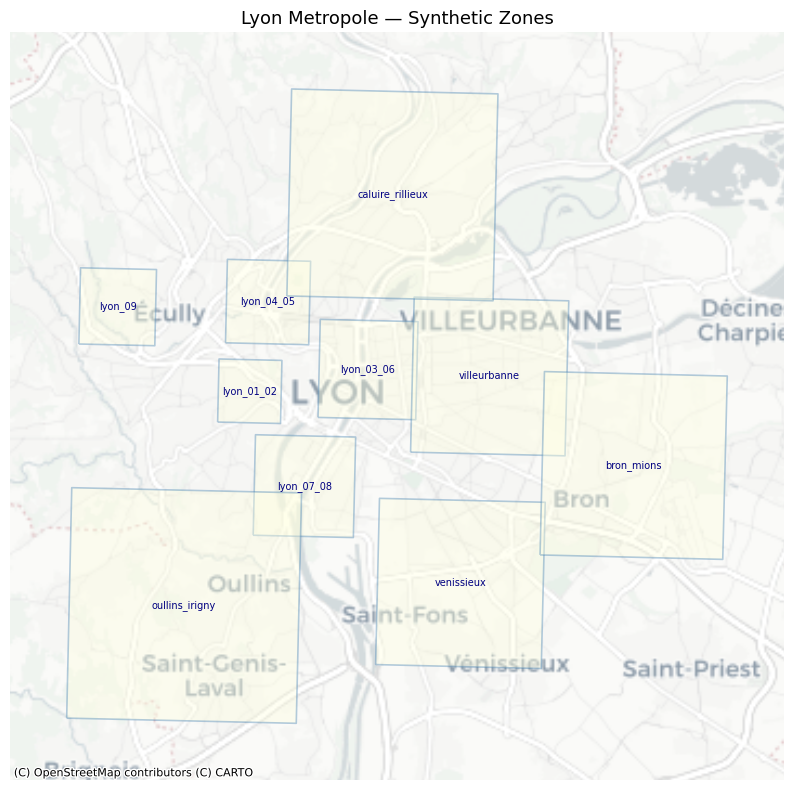

Saved lyon_01_zones.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
zones_3857 = zones.to_crs(epsg=3857)
zones_3857.plot(ax=ax, alpha=0.4, edgecolor="steelblue", linewidth=1.2, facecolor="lightyellow")
for _, row in zones_3857.iterrows():
    ax.annotate(
        row["zone_id"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", va="center", fontsize=7, color="navy",
    )
add_basemap(ax, gdf_3857=zones_3857, crs="EPSG:3857", zoom=11)
ax.set_title("Lyon Metropole — Synthetic Zones", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/lyon_01_zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lyon_01_zones.png")

## 2. Synthetic population

One representative record per zone with `n_households` = actual count.
`FranceDemandModel` reads the `n_households` column to compute zone demand directly
— no need to enumerate individual household rows.

In [4]:
# One record per zone: the France model aggregates by zone_id using n_households column
rows = []
for _, zone in zones.iterrows():
    rows.append({
        "household_id": zone["zone_id"],
        "zone_id": zone["zone_id"],
        "geometry": Point(zone["centroid_x"], zone["centroid_y"]),
        "n_persons": 2,
        "income_bracket": "median",
        "n_households": float(zone["n_households"]),
    })

households = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)

population = SyntheticPopulation(
    city=city,
    households=households,
    source_adapter="synthetic_lyon",
    year=2024,
)
print(population.summary())
print(f"Household records: {len(households)} (one per zone)")
print(f"Total n_households: {households['n_households'].sum():,.0f}")

SyntheticPopulation [synthetic_lyon, 2024]
  City:        lyon
  Households:  10
  Persons:     20
  Zones:       10
  Income dist: median=10
Household records: 10 (one per zone)
Total n_households: 361,000


## 3. Parcel demand — France model

Gardrat (2019) / Hörl et al. (2025): 14 annual e-purchases/hh × 1.35 growth factor × 47% home delivery rate ÷ 260 delivery days = **0.034 parcels/hh/day**.

In [5]:
france_model = FranceDemandModel(
    annual_purchases_per_hh=14.0,
    home_delivery_fraction=0.47,
    demand_factor=1.35,   # 2024 baseline (Horl Table 5)
    delivery_days_per_year=260,
    seed=42,
)
print(f"Daily rate per household: {france_model.daily_rate_per_hh:.4f} parcels/hh/day")

demand = france_model.generate(population)
print(f"\nTotal deliveries:  {demand.total_delivery:>10,.0f} /day")
print(f"Total pickups:     {demand.total_pickup:>10,.0f} /day")
print(f"Zones modelled:    {len(demand.zone_demand)}")
demand.zone_demand[["zone_id","n_delivery"]].sort_values("n_delivery", ascending=False)

Daily rate per household: 0.0342 parcels/hh/day

Total deliveries:      12,366 /day
Total pickups:              0 /day
Zones modelled:    10


,zone_id,n_delivery
5,villeurbanne,2441.0
1,lyon_03_06,1551.0
3,lyon_07_08,1396.0
2,lyon_04_05,1342.0
8,caluire_rillieux,1235.0
9,oullins_irigny,1129.0
6,venissieux,969.0
4,lyon_09,816.0
7,bron_mions,747.0
0,lyon_01_02,740.0


### Demand distribution map

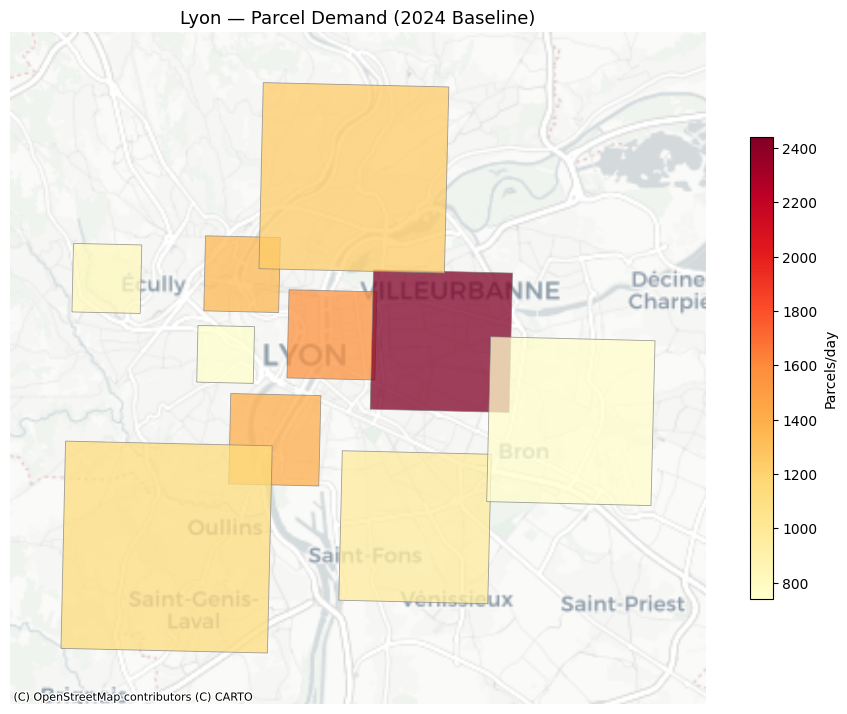

In [6]:
merged = zones.merge(demand.zone_demand[["zone_id","n_delivery"]], on="zone_id")
merged_3857 = merged.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 8))
merged_3857.plot(
    column="n_delivery", ax=ax, cmap="YlOrRd",
    legend=True, legend_kwds={"label":"Parcels/day","shrink":0.6},
    alpha=0.75, edgecolor="gray", linewidth=0.6
)
add_basemap(ax, gdf_3857=merged_3857, crs="EPSG:3857", zoom=11)
ax.set_title("Lyon — Parcel Demand (2024 Baseline)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/lyon_02_demand.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Operator registry — Lyon 2024

Eight carriers from Hörl et al. (2025) Table 3, with depot coordinates from Figure 2.

In [7]:
registry = OperatorRegistry.from_builtin("lyon_2024")

op_df = pd.DataFrame([
    {"Operator": op.name, "Market share": f"{op.market_share*100:.2f}%",
     "N depots": len(op.depots)}
    for op in registry.operators
])
op_df = op_df.sort_values("Market share", ascending=False).reset_index(drop=True)
print(f"Total operators: {len(registry.operators)}")
print(f"Market share sum: {sum(op.market_share for op in registry.operators):.4f}")
op_df

Total operators: 8
Market share sum: 0.9999


,Operator,Market share,N depots
0,DPD,9.95%,3
1,DHL,8.95%,7
2,GLS,6.93%,2
3,Colis Privé,5.36%,2
4,Colissimo (La Poste),40.07%,8
5,Chronopost,14.97%,6
6,UPS,13.55%,2
7,FedEx,0.21%,8


## 5. Parcel assignment (nearest depot)

In [8]:
assignment = assign_parcels(demand, registry, city)
print("Zone assignments shape:", assignment.zone_assignments.shape)
cols = [c for c in assignment.zone_assignments.columns if "_delivery" in c or c == "zone_id"]
assignment.zone_assignments[cols].head()

Zone assignments shape: (10, 40)


,zone_id,n_delivery,colissimo_delivery,chronopost_delivery,ups_delivery,dpd_delivery,dhl_delivery,gls_delivery,colis_prive_delivery,fedex_delivery
0,lyon_01_02,740.0,296.5180,110.7780,100.2700,73.6300,66.2300,51.2820,39.6640,1.5540
1,lyon_03_06,1551.0,621.4857,232.1847,210.1605,154.3245,138.8145,107.4843,83.1336,3.2571
2,lyon_04_05,1342.0,537.7394,200.8974,181.8410,133.5290,120.1090,93.0006,71.9312,2.8182
3,lyon_07_08,1396.0,559.3772,208.9812,189.1580,138.9020,124.9420,96.7428,74.8256,2.9316
4,lyon_09,816.0,326.9712,122.1552,110.5680,81.1920,73.0320,56.5488,43.7376,1.7136


### Assignment map — dominant carrier per zone

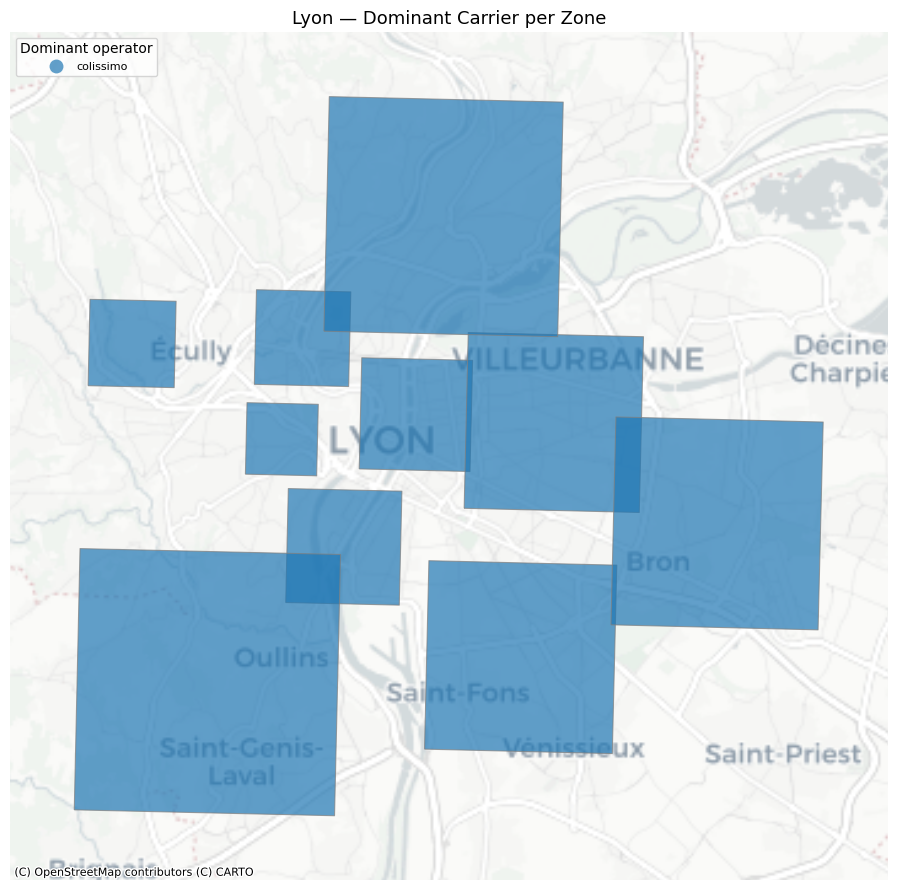

In [9]:
za = assignment.zone_assignments.copy()
# Use explicit operator IDs to avoid picking up n_delivery which also ends with _delivery
delivery_cols = [f"{op.operator_id}_delivery" for op in registry.operators
                 if f"{op.operator_id}_delivery" in za.columns]
za["dominant_operator"] = za[delivery_cols].idxmax(axis=1).str.replace("_delivery","")

merged2 = zones.merge(za[["zone_id","dominant_operator"]], on="zone_id")
merged2_3857 = merged2.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 9))
merged2_3857.plot(
    column="dominant_operator", ax=ax,
    legend=True, alpha=0.7, edgecolor="gray", linewidth=0.8,
    categorical=True,
    legend_kwds={"loc":"upper left", "fontsize":8, "title":"Dominant operator"}
)
depots_gdf = registry.all_depots(crs=CRS).to_crs(epsg=3857)
depots_gdf.plot(ax=ax, color="black", markersize=30, zorder=5, marker="^")
add_basemap(ax, gdf_3857=merged2_3857, crs="EPSG:3857", zoom=11)
ax.set_title("Lyon — Dominant Carrier per Zone", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/lyon_03_assignment.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. VRP routing (medium ICV, OR-Tools CVRP)

In [10]:
router = VRPRouter(
    vehicle_type="medium_icv",   # 50 parcels/vehicle, 260 EUR/month
    max_vehicles=40,
    time_limit_seconds=10,
)
vrp_result = router.solve(assignment, city)
print(vrp_result.summary())

VRPResult  scenario=baseline
  Total VKT:         2,901.3 km/day
  Total vehicles:        260
  Total cost:         27,566 EUR/day
  By operator:
    colissimo     VKT=    435.1 km  vehicles= 102  cost=  10,738 EUR
    chronopost    VKT=    413.4 km  vehicles=  38  cost=   4,028 EUR
    ups           VKT=    788.0 km  vehicles=  35  cost=   3,754 EUR
    dpd           VKT=    322.8 km  vehicles=  26  cost=   2,760 EUR
    dhl           VKT=    267.1 km  vehicles=  24  cost=   2,544 EUR
    gls           VKT=    380.8 km  vehicles=  18  cost=   1,928 EUR
    colis_prive   VKT=    241.7 km  vehicles=  14  cost=   1,494 EUR
    fedex         VKT=     52.5 km  vehicles=   3  cost=     320 EUR


## 7. KPI report

In [11]:
report = KPIReport.from_vrp(
    vrp_result, assignment, emission_factor="fr_icv_small"
)
print(report.summary())
print(f"\nTotal cost:      {report.cost_total:>12,.0f} EUR/day")
print(f"Cost per parcel: {report.cost_per_parcel:>12.2f} EUR")

──────────────────────────────────────────────────
KPIReport  [VRP]  scenario=baseline
──────────────────────────────────────────────────
  Parcels delivered:        12,366 /day
  Parcels picked up:             0 /day
  Total VKT:               2,901.3 km/day
  Active trucks:               260
  GHG emissions:             377.2 kg CO₂eq/day
  GHG (MTCE):                 0.38 MTCE/day
  GHG per parcel:             30.5 g CO₂eq
  By operator:
    colissimo   parcels=   4,955  VKT=    435.1 km  trucks= 102
    chronopost  parcels=   1,851  VKT=    413.4 km  trucks=  38
    ups         parcels=   1,676  VKT=    788.0 km  trucks=  35
    dpd         parcels=   1,230  VKT=    322.8 km  trucks=  26
    dhl         parcels=   1,107  VKT=    267.1 km  trucks=  24
    gls         parcels=     857  VKT=    380.8 km  trucks=  18
    colis_prive  parcels=     663  VKT=    241.7 km  trucks=  14
    fedex       parcels=      26  VKT=     52.5 km  trucks=   3
──────────────────────────────────────────

## 8. Scenario comparison

Replicating Hörl et al. (2025) Table 6 scenario analysis.
The `demand_factor` for 2030 = 2.00 / 1.35 relative to the 2024 base (the router
multiplies the already-2024-scaled demand by this factor).

In [12]:
scenarios = {
    "2024 Baseline":  {"vt": "medium_icv", "ef": "fr_icv_small",
                       "s": Scenario(name="2024_baseline", demand_factor=1.0, peak_factor=1.0)},
    "2030 BAU":       {"vt": "medium_icv", "ef": "fr_icv_small",
                       "s": Scenario(name="2030_bau", demand_factor=2.0/1.35, peak_factor=1.0)},
    "100% BEV":       {"vt": "medium_bev", "ef": "fr_bev_small",
                       "s": Scenario(name="2024_bev", demand_factor=1.0, peak_factor=1.0)},
    "2030 + BEV":     {"vt": "medium_bev", "ef": "fr_bev_small",
                       "s": Scenario(name="2030_bev", demand_factor=2.0/1.35, peak_factor=1.0)},
}

results_table = []
for label, cfg in scenarios.items():
    r = VRPRouter(vehicle_type=cfg["vt"], time_limit_seconds=10)
    res = r.solve(assignment, city, scenario=cfg["s"])
    kpi = KPIReport.from_vrp(res, assignment, emission_factor=cfg["ef"])
    results_table.append({
        "Scenario": label,
        "VKT (km/day)": f"{kpi.vkt_total_km:,.0f}",
        "Vehicles": kpi.n_trucks_total,
        "GHG (kg CO2eq)": f"{kpi.ghg_kg_co2eq:,.0f}",
        "Cost (EUR/day)": f"{kpi.cost_total:,.0f}",
        "Cost/parcel (EUR)": f"{kpi.cost_per_parcel:.2f}",
    })

pd.DataFrame(results_table).set_index("Scenario")

,VKT (km/day),Vehicles,GHG (kg CO2eq),Cost (EUR/day),Cost/parcel (EUR)
Scenario,,,,,
2024 Baseline,"2,901",260,377,"27,566",2.23
2030 BAU,"4,142",367,538,"38,916",3.15
100% BEV,"2,901",260,42,"29,067",2.35
2030 + BEV,"4,142",367,60,"41,032",3.32


## 9. CA vs VRP comparison

Quick sanity check: the Continuous Approximation formula should give similar aggregate VKT to the OR-Tools VRP.

In [13]:
ca_result = CARouter().solve(assignment, city)
ca_report = KPIReport.from_ca(ca_result, assignment)

comparison = pd.DataFrame([
    {"Method": "CA (Daganzo)", "VKT (km/day)": f"{ca_report.vkt_total_km:,.0f}",
     "Trucks": ca_report.n_trucks_total, "GHG (kg)": f"{ca_report.ghg_kg_co2eq:,.0f}"},
    {"Method": "VRP (OR-Tools)", "VKT (km/day)": f"{report.vkt_total_km:,.0f}",
     "Trucks": report.n_trucks_total, "GHG (kg)": f"{report.ghg_kg_co2eq:,.0f}"},
])
print(comparison.to_string(index=False))
ratio = ca_report.vkt_total_km / report.vkt_total_km if report.vkt_total_km > 0 else float("nan")
print(f"\nCA / VRP ratio: {ratio:.2f}  (expect ~0.8-1.2 for planning-level zones)")

        Method VKT (km/day)  Trucks GHG (kg)
  CA (Daganzo)        3,160      47      460
VRP (OR-Tools)        2,901     260      377

CA / VRP ratio: 1.09  (expect ~0.8-1.2 for planning-level zones)


## 10. Pipeline summary

In [14]:
sep = "=" * 58
print(sep)
print("  Lyon Last-Mile Delivery — Pipeline Summary")
print(sep)
print(f"  Study area:          Lyon Metropole (synthetic zones)")
print(f"  Households:          {total_hh:>12,}")
print(f"  Parcels/day:         {demand.total_delivery:>12,.0f}")
print(f"  Operators:           {len(registry.operators):>12}  (8 French carriers)")
print(f"  Routing method:      {'VRP (OR-Tools CVRP)':>12}")
print(f"  Vehicles (baseline): {report.n_trucks_total:>12}")
print(f"  VKT (baseline):      {report.vkt_total_km:>12,.1f} km/day")
print(f"  GHG (baseline):      {report.ghg_kg_co2eq:>12,.1f} kg CO2eq/day")
print(f"  Cost (baseline):     {report.cost_total:>12,.0f} EUR/day")
print(f"  Cost per parcel:     {report.cost_per_parcel:>12.2f} EUR")
print(sep)

  Lyon Last-Mile Delivery — Pipeline Summary
  Study area:          Lyon Metropole (synthetic zones)
  Households:               361,000
  Parcels/day:               12,366
  Operators:                      8  (8 French carriers)
  Routing method:      VRP (OR-Tools CVRP)
  Vehicles (baseline):          260
  VKT (baseline):           2,901.3 km/day
  GHG (baseline):             377.2 kg CO2eq/day
  Cost (baseline):           27,566 EUR/day
  Cost per parcel:             2.23 EUR
